In [1]:
import pandas as pd
print(pd.__version__)

3.0.5


In [2]:
# Load the dataset
df = pd.read_csv('../data/train.csv')

# Check basic shape and structure
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Shape: (913000, 4)

Columns: ['date', 'store', 'item', 'sales']

Data types:
date       str
store    int64
item     int64
sales    int64
dtype: object


In [3]:
# Look at the first few rows
print(df.head())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Check the actual date range and unique counts
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("Unique stores:", df['store'].nunique())
print("Unique items:", df['item'].nunique())

# Basic statistics on the sales column
print("\nSales statistics:")
print(df['sales'].describe())

         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10

Missing values per column:
date     0
store    0
item     0
sales    0
dtype: int64

Date range: 2013-01-01 to 2017-12-31
Unique stores: 10
Unique items: 50

Sales statistics:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


In [4]:
# Convert 'date' column from text to actual datetime type
df['date'] = pd.to_datetime(df['date'])

# Check for duplicate store-item-date combinations
duplicate_count = df.duplicated(subset=['date', 'store', 'item']).sum()
print(f"Duplicate store-item-date combinations: {duplicate_count}")

# Sort data chronologically within each store-item group
df = df.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)

# Check for negative sales (shouldn't exist)
negative_sales = (df['sales'] < 0).sum()
print(f"Negative sales values: {negative_sales}")

# Confirm the date column type changed
print(f"\nDate column type now: {df['date'].dtype}")
print(f"Date range after conversion: {df['date'].min()} to {df['date'].max()}")

Duplicate store-item-date combinations: 0
Negative sales values: 0

Date column type now: datetime64[us]
Date range after conversion: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


In [5]:
# Check for extreme outliers using mean + 3*std rule
mean_sales = df['sales'].mean()
std_sales = df['sales'].std()
outlier_threshold = mean_sales + 3 * std_sales

extreme_outliers = df[df['sales'] > outlier_threshold]
print(f"Outlier threshold (mean + 3*std): {outlier_threshold:.2f}")
print(f"Rows above threshold: {len(extreme_outliers)}")

# Look at a sample of these outlier rows
print("\nSample outlier rows:")
print(extreme_outliers.sample(5, random_state=1))

# Check which months these outliers cluster in
print("\nMonth distribution of outliers:")
print(extreme_outliers['date'].dt.month.value_counts().sort_index())


Outlier threshold (mean + 3*std): 138.65
Rows above threshold: 6975

Sample outlier rows:
             date  store  item  sales
182464 2017-08-18      2    50    144
890912 2017-07-09     10    38    148
684608 2017-08-12      8    25    146
665963 2016-07-23      8    15    160
845199 2017-05-07     10    13    139

Month distribution of outliers:
date
3       32
4      365
5      790
6     1461
7     2664
8      805
9      363
10     149
11     346
Name: count, dtype: int64


In [6]:
df.to_csv('../data/train_cleaned.csv', index=False)
print("Saved cleaned file. Shape:", df.shape)

Saved cleaned file. Shape: (913000, 4)


In [7]:
import sqlite3

# Reload the cleaned data with proper date parsing
df = pd.read_csv('../data/train_cleaned.csv', parse_dates=['date'])

# Create an in-memory SQLite database and load our dataframe into it as a table
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

print("Database ready. Table 'sales' created with", len(df), "rows.")

Database ready. Table 'sales' created with 913000 rows.


In [8]:
# Query 1: Total sales by store
q1 = """
SELECT store, SUM(sales) AS total_sales, ROUND(AVG(sales),2) AS avg_daily_sales
FROM sales
GROUP BY store
ORDER BY total_sales DESC
"""
print("STORE PERFORMANCE:")
print(pd.read_sql(q1, conn))

STORE PERFORMANCE:
   store  total_sales  avg_daily_sales
0      2      6120128            67.03
1      8      5856169            64.14
2      3      5435144            59.53
3     10      5360158            58.71
4      9      5025976            55.05
5      4      5012639            54.90
6      1      4315603            47.27
7      5      3631016            39.77
8      6      3627670            39.73
9      7      3320009            36.36


In [9]:
# Query 2: Top and bottom 5 items
q2_top = """
SELECT item, SUM(sales) AS total_sales
FROM sales
GROUP BY item
ORDER BY total_sales DESC
LIMIT 5
"""
q2_bottom = """
SELECT item, SUM(sales) AS total_sales
FROM sales
GROUP BY item
ORDER BY total_sales ASC
LIMIT 5
"""
print("TOP 5 ITEMS:")
print(pd.read_sql(q2_top, conn))
print("\nBOTTOM 5 ITEMS:")
print(pd.read_sql(q2_bottom, conn))

TOP 5 ITEMS:
   item  total_sales
0    15      1607442
1    28      1604713
2    13      1539621
3    18      1538876
4    25      1473334

BOTTOM 5 ITEMS:
   item  total_sales
0     5       335230
1     1       401384
2    41       401759
3    47       401781
4     4       401907


In [10]:
# Query 3: Yearly trend
q3 = """
SELECT strftime('%Y', date) AS year, SUM(sales) AS total_sales
FROM sales
GROUP BY year
ORDER BY year
"""
print("YEARLY TREND:")
print(pd.read_sql(q3, conn))

# Query 4: Monthly seasonality
q4 = """
SELECT strftime('%m', date) AS month, ROUND(AVG(sales),2) AS avg_sales
FROM sales
GROUP BY month
ORDER BY month
"""
print("\nMONTHLY SEASONALITY:")
print(pd.read_sql(q4, conn))

YEARLY TREND:
   year  total_sales
0  2013      7941243
1  2014      9135482
2  2015      9536887
3  2016     10357160
4  2017     10733740

MONTHLY SEASONALITY:
   month  avg_sales
0     01      35.52
1     02      39.38
2     03      47.31
3     04      55.15
4     05      59.13
5     06      63.03
6     07      67.00
7     08      59.11
8     09      55.07
9     10      51.19
10    11      55.22
11    12      39.37


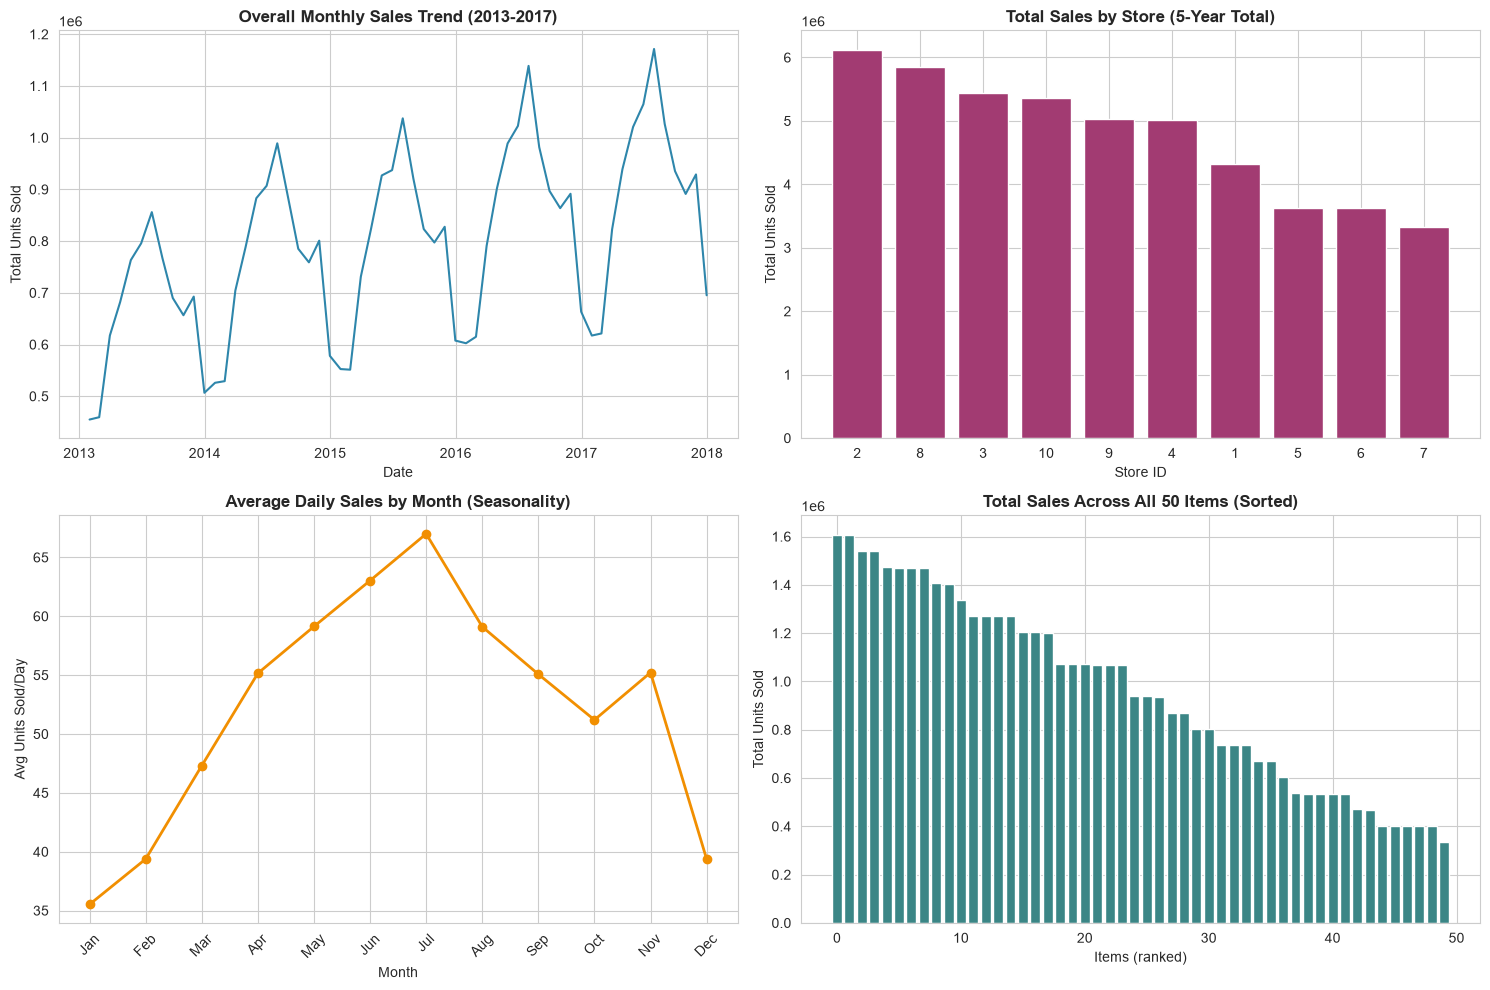

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Overall monthly sales trend (smoothed)
monthly_total = df.set_index('date').resample('ME')['sales'].sum()
axes[0,0].plot(monthly_total.index, monthly_total.values, color='#2E86AB', linewidth=1.5)
axes[0,0].set_title('Overall Monthly Sales Trend (2013-2017)', fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Total Units Sold')

# 2. Store-level comparison
store_totals = df.groupby('store')['sales'].sum().sort_values(ascending=False)
axes[0,1].bar(store_totals.index.astype(str), store_totals.values, color='#A23B72')
axes[0,1].set_title('Total Sales by Store (5-Year Total)', fontweight='bold')
axes[0,1].set_xlabel('Store ID')
axes[0,1].set_ylabel('Total Units Sold')

# 3. Monthly seasonality
df['month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,0].plot(month_names, monthly_avg.values, marker='o', color='#F18F01', linewidth=2)
axes[1,0].set_title('Average Daily Sales by Month (Seasonality)', fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Avg Units Sold/Day')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Item-level distribution (all 50 items, sorted)
item_totals = df.groupby('item')['sales'].sum().sort_values(ascending=False)
axes[1,1].bar(range(len(item_totals)), item_totals.values, color='#3B8686')
axes[1,1].set_title('Total Sales Across All 50 Items (Sorted)', fontweight='bold')
axes[1,1].set_xlabel('Items (ranked)')
axes[1,1].set_ylabel('Total Units Sold')

plt.tight_layout()
plt.savefig('../outputs/eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
!pip install statsmodels --quiet


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\ehsan\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


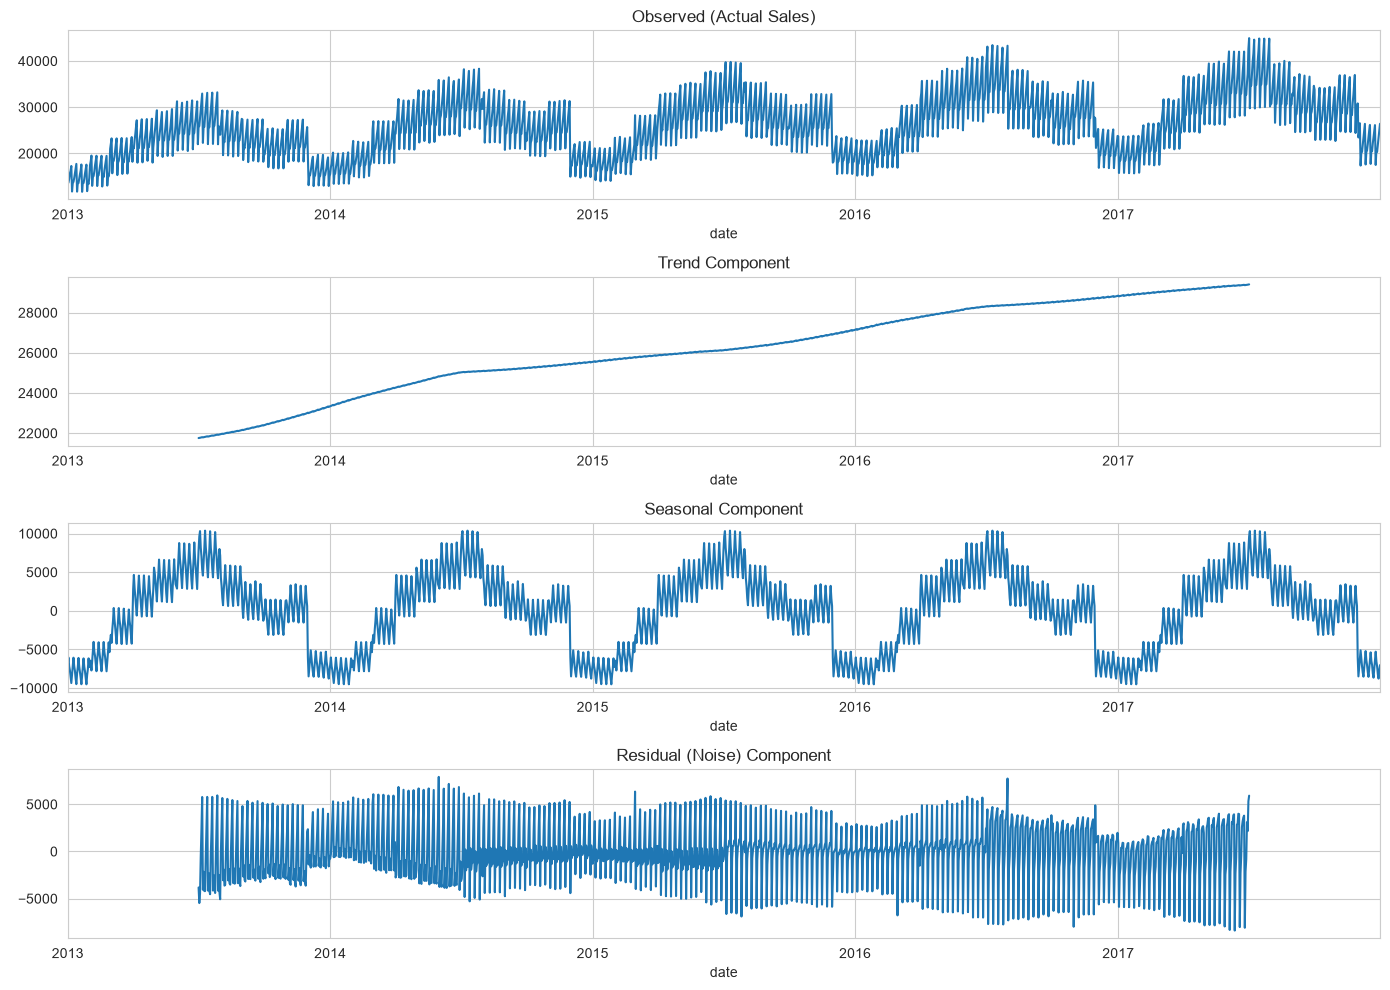

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aggregate to daily total sales across all stores/items (one overall series)
daily_sales = df.groupby('date')['sales'].sum()

# Decompose using an additive model, period=365 (yearly seasonality in daily data)
decomposition = seasonal_decompose(daily_sales, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed (Actual Sales)')
decomposition.trend.plot(ax=axes[1], title='Trend Component')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise) Component')
plt.tight_layout()
plt.savefig('../outputs/time_series_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales)

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("\nCritical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("\n=> Series is STATIONARY (reject null hypothesis)")
else:
    print("\n=> Series is NON-STATIONARY (fail to reject null hypothesis)")

ADF Statistic: -3.0602
p-value: 0.0296

Critical Values:
   1%: -3.4340
   5%: -2.8631
   10%: -2.5676

=> Series is STATIONARY (reject null hypothesis)


C:\Users\ehsan\AppData\Local\Temp\ipykernel_37588\3046934570.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(daily_sales)


In [15]:
# Make sure data is sorted correctly (store, item, then chronological date)
df = df.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)

# --- A. Calendar features ---
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek   # Monday=0, Sunday=6
df['day_of_year'] = df['date'].dt.dayofyear
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# --- B. Lag features (grouped by store+item to prevent leakage across series) ---
df['sales_lag_1'] = df.groupby(['store', 'item'])['sales'].shift(1)
df['sales_lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
df['sales_lag_365'] = df.groupby(['store', 'item'])['sales'].shift(365)

# --- C. Rolling window features (also grouped, and shifted to avoid using today's value) ---
df['rolling_mean_7'] = df.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)
df['rolling_mean_30'] = df.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).rolling(window=30).mean()
)

print("New columns created:")
print(df.columns.tolist())
print("\nShape after feature engineering:", df.shape)
print("\nMissing values introduced by lag/rolling features:")
print(df[['sales_lag_1','sales_lag_7','sales_lag_365','rolling_mean_7','rolling_mean_30']].isnull().sum())

New columns created:
['date', 'store', 'item', 'sales', 'month', 'year', 'day', 'day_of_week', 'day_of_year', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_365', 'rolling_mean_7', 'rolling_mean_30']

Shape after feature engineering: (913000, 15)

Missing values introduced by lag/rolling features:
sales_lag_1           500
sales_lag_7          3500
sales_lag_365      182500
rolling_mean_7       3500
rolling_mean_30     15000
dtype: int64


In [16]:
# Drop rows where our longest lag feature (365 days) is missing
df_model_ready = df.dropna(subset=['sales_lag_365']).reset_index(drop=True)

print("Shape before dropping:", df.shape)
print("Shape after dropping:", df_model_ready.shape)
print("\nRemaining missing values check:")
print(df_model_ready.isnull().sum().sum(), "total missing values left")

# Save this feature-engineered, model-ready dataset
df_model_ready.to_csv('../data/train_features.csv', index=False)
print("\nSaved train_features.csv")

Shape before dropping: (913000, 15)
Shape after dropping: (730500, 15)

Remaining missing values check:
0 total missing values left

Saved train_features.csv


In [17]:
# Chronological split: last 90 days = test set, everything before = train set
split_date = df_model_ready['date'].max() - pd.Timedelta(days=90)

train = df_model_ready[df_model_ready['date'] <= split_date]
test = df_model_ready[df_model_ready['date'] > split_date]

print(f"Split date: {split_date}")
print(f"Train shape: {train.shape}, from {train['date'].min()} to {train['date'].max()}")
print(f"Test shape: {test.shape}, from {test['date'].min()} to {test['date'].max()}")

Split date: 2017-10-02 00:00:00
Train shape: (685500, 15), from 2014-01-01 00:00:00 to 2017-10-02 00:00:00
Test shape: (45000, 15), from 2017-10-03 00:00:00 to 2017-12-31 00:00:00


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%\n")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Baseline 1: Naive forecast (yesterday's sales = today's prediction)
naive_preds = test['sales_lag_1']
naive_results = evaluate(test['sales'], naive_preds, "Naive (lag_1)")

# Baseline 2: Seasonal naive forecast (same day last year = today's prediction)
seasonal_naive_preds = test['sales_lag_365']
seasonal_naive_results = evaluate(test['sales'], seasonal_naive_preds, "Seasonal Naive (lag_365)")

--- Naive (lag_1) ---
MAE:  10.65
RMSE: 14.47
MAPE: 22.88%

--- Seasonal Naive (lag_365) ---
MAE:  10.79
RMSE: 14.36
MAPE: 22.57%



In [19]:
from sklearn.linear_model import LinearRegression

# Define our feature columns (consistent across all models for fair comparison)
feature_cols = ['store', 'item', 'year', 'month', 'day', 'day_of_week', 
                 'day_of_year', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 
                 'sales_lag_365', 'rolling_mean_7', 'rolling_mean_30']

target_col = 'sales'

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test)

# Evaluate using our reusable function from before
lr_results = evaluate(y_test, lr_preds, "Linear Regression")

--- Linear Regression ---
MAE:  7.16
RMSE: 9.35
MAPE: 15.88%



In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,     # number of trees in the forest
    max_depth=15,         # limits tree depth to prevent overfitting
    random_state=42,      # for reproducibility
    n_jobs=-1              # use all CPU cores to speed up training
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_results = evaluate(y_test, rf_preds, "Random Forest")

--- Random Forest ---
MAE:  6.15
RMSE: 8.02
MAPE: 13.49%



In [23]:
import pandas as pd

importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances)

            feature  importance
9       sales_lag_7    0.766565
11   rolling_mean_7    0.158992
5       day_of_week    0.022042
8       sales_lag_1    0.014721
10    sales_lag_365    0.012502
12  rolling_mean_30    0.011591
6       day_of_year    0.004958
4               day    0.003349
3             month    0.001589
1              item    0.001510
0             store    0.000907
7        is_weekend    0.000789
2              year    0.000485


In [24]:
# Check how correlated our lag/rolling features are with each other and with sales
corr_check = train[['sales', 'sales_lag_1', 'sales_lag_7', 'sales_lag_365', 
                      'rolling_mean_7', 'rolling_mean_30']].corr()
print(corr_check['sales'].sort_values(ascending=False))

sales              1.000000
sales_lag_7        0.930630
rolling_mean_7     0.925764
rolling_mean_30    0.920777
sales_lag_1        0.878335
sales_lag_365      0.875032
Name: sales, dtype: float64


In [25]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_results = evaluate(y_test, xgb_preds, "XGBoost")

--- XGBoost ---
MAE:  5.93
RMSE: 7.68
MAPE: 13.05%



In [26]:
import pickle

# Save the trained XGBoost model for later use in Streamlit dashboard
with open('../outputs/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save a comparison table of all models for documentation/README later
comparison_df = pd.DataFrame([
    {'model': 'Naive (lag_1)', 'MAE': 10.65, 'RMSE': 14.47, 'MAPE': 22.88},
    {'model': 'Seasonal Naive (lag_365)', 'MAE': 10.79, 'RMSE': 14.36, 'MAPE': 22.57},
    {'model': 'Linear Regression', 'MAE': 7.16, 'RMSE': 9.35, 'MAPE': 15.88},
    {'model': 'Random Forest', 'MAE': 6.15, 'RMSE': 8.02, 'MAPE': 13.49},
    {'model': 'XGBoost', 'MAE': 5.93, 'RMSE': 7.68, 'MAPE': 13.05},
])
comparison_df.to_csv('../outputs/model_comparison.csv', index=False)
print("Saved model and comparison table.")
print(comparison_df)

Saved model and comparison table.
                      model    MAE   RMSE   MAPE
0             Naive (lag_1)  10.65  14.47  22.88
1  Seasonal Naive (lag_365)  10.79  14.36  22.57
2         Linear Regression   7.16   9.35  15.88
3             Random Forest   6.15   8.02  13.49
4                   XGBoost   5.93   7.68  13.05


In [27]:
from scipy.stats import norm

# --- ASSUMPTIONS (clearly labeled, since dataset lacks this info) ---
LEAD_TIME_DAYS = 7          # Assumption: typical retail replenishment lead time
SERVICE_LEVEL = 0.95        # Assumption: 95% service level (industry-common default)
Z_SCORE = norm.ppf(SERVICE_LEVEL)  # Converts service level % into a Z-score

print(f"Using Z-score for {SERVICE_LEVEL*100}% service level: {Z_SCORE:.3f}")

# --- CALCULATED VALUES (derived from actual historical data) ---
# Calculate average daily demand and demand variability PER store-item combination
demand_stats = df_model_ready.groupby(['store', 'item'])['sales'].agg(
    avg_daily_demand='mean',
    demand_std='std'
).reset_index()

# --- Safety Stock & Reorder Point formulas ---
demand_stats['safety_stock'] = (
    Z_SCORE * demand_stats['demand_std'] * np.sqrt(LEAD_TIME_DAYS)
).round().astype(int)

demand_stats['reorder_point'] = (
    (demand_stats['avg_daily_demand'] * LEAD_TIME_DAYS) + demand_stats['safety_stock']
).round().astype(int)

print(demand_stats.head(10))
print(f"\nTotal store-item combinations: {len(demand_stats)}")

Using Z-score for 95.0% service level: 1.645
   store  item  avg_daily_demand  demand_std  safety_stock  reorder_point
0      1     1         20.837098    6.732116            29            175
1      1     2         55.451061   14.833776            65            453
2      1     3         34.591376   10.036954            44            286
3      1     4         20.804244    6.588284            29            175
4      1     5         17.339493    5.684611            25            146
5      1     6         55.240931   14.623803            64            451
6      1     7         54.818617   15.114878            66            450
7      1     8         72.377823   18.516143            81            588
8      1     9         48.403149   13.093749            57            396
9      1    10         69.250513   18.094772            79            564

Total store-item combinations: 500


In [28]:
# Use XGBoost predictions on the test set (most recent 90 days) as our forward-looking demand estimate
test_with_preds = test.copy()
test_with_preds['predicted_demand'] = xgb_preds

# Average predicted daily demand per store-item over this recent test window
forecast_demand = test_with_preds.groupby(['store', 'item'])['predicted_demand'].mean().reset_index()
forecast_demand.rename(columns={'predicted_demand': 'forecasted_avg_daily_demand'}, inplace=True)

# Merge with our historical demand_std (variability is more stable to estimate from full history)
inventory_plan = forecast_demand.merge(
    demand_stats[['store', 'item', 'demand_std']], 
    on=['store', 'item']
)

# Recalculate safety stock and reorder point using FORECASTED demand
inventory_plan['safety_stock'] = (
    Z_SCORE * inventory_plan['demand_std'] * np.sqrt(LEAD_TIME_DAYS)
).round().astype(int)

inventory_plan['reorder_point'] = (
    (inventory_plan['forecasted_avg_daily_demand'] * LEAD_TIME_DAYS) + inventory_plan['safety_stock']
).round().astype(int)

print(inventory_plan.head(10))

# Save this final inventory plan
inventory_plan.to_csv('../outputs/inventory_plan.csv', index=False)
print("\nSaved inventory_plan.csv")

   store  item  forecasted_avg_daily_demand  demand_std  safety_stock  \
0      1     1                    20.381895    6.732116            29   
1      1     2                    55.934093   14.833776            65   
2      1     3                    34.115158   10.036954            44   
3      1     4                    20.414003    6.588284            29   
4      1     5                    17.224688    5.684611            25   
5      1     6                    55.919899   14.623803            64   
6      1     7                    55.030750   15.114878            66   
7      1     8                    73.246513   18.516143            81   
8      1     9                    47.527218   13.093749            57   
9      1    10                    69.835571   18.094772            79   

   reorder_point  
0            172  
1            457  
2            283  
3            172  
4            146  
5            455  
6            451  
7            594  
8            390  
9     

In [1]:
import os
print(os.getcwd())

C:\Users\ehsan\sales-demand-forecasting\notebooks
